# 00a — TỪ ĐIỂN 70 TRƯỜNG DỮ LIỆU · Synthetic Quote-Context (TP.HCM, VND)

Tài liệu tổng quan bộ dữ liệu mới anh mentor gửi. Gồm 3 phần:
1. **Giải thích chi tiết các trường** (phân theo nhóm)
2. **Tổng quan dữ liệu**
3. **Dữ liệu thiếu**

| | |
|---|---|
| Bối cảnh | 3 khu TP.HCM: Crescent Mall · SC Vivo City · EcoGreen Sài Gòn |
| Thời gian | 01/01 – 30/03/2026 · tần suất 5 phút · 89 ngày |
| Tiền tệ | **VND** · 2 dịch vụ (Standard / Premium) · đối thủ "Synthetic Competitor" |
| Bảng chính | `synthetic_intern_forecasting_v1` — **6,9M dòng × 70 cột** |

---
# 1️⃣ Giải thích chi tiết các trường (theo nhóm)

70 trường được chia theo cột **`forecasting_availability`** — cho biết trường nào **được dùng làm
feature**, trường nào **CẤM dùng** (leakage).

| Nhóm khả dụng | Ý nghĩa | Dùng làm feature? |
|---|---|---|
| `available_at_quote_request` | Ngữ cảnh biết trước lúc báo giá | ✅ |
| `available_past_only` | Từ quan sát quá khứ (lag, history) | ✅ |
| `available_if_observed_by_target` | Thời tiết (nếu quan sát kịp) | ✅ (cẩn thận thiếu) |
| `identifier_or_evaluation_only` | Định danh / đánh giá | ❌ leakage |
| `label_hidden_at_target` | Biến mục tiêu | 🎯 target |

## 🎯 Nhóm TARGET — 3 biến mục tiêu cần dự đoán
*(bị ẩn tại thời điểm dự báo — đây là thứ model phải đoán ra)*

| Trường | Ý nghĩa |
|---|---|
| `target_shown_price` | **Giá đối thủ hiển thị** cho khách — biến dự đoán chính |
| `target_shown_multiplier` | **Hệ số nhân (surge)** đối thủ đang áp dụng |
| `target_price_per_km` | Giá trên mỗi km (= giá / quãng đường) — target phụ |

## 🚫 Nhóm ĐỊNH DANH & ĐÁNH GIÁ — CẤM dùng làm feature

| Trường | Ý nghĩa |
|---|---|
| `forecast_example_id` | Mã định danh mỗi dòng dự báo |
| `target_request_id` | Mã yêu cầu báo giá |
| `evaluation_month` | Tháng đánh giá (2026-01/02/03) — chia fold |
| `scenario_id` | Mã kịch bản sinh dữ liệu |
| `split` | Nhãn train / validation / calibration / test |
| `is_synthetic` | Luôn = True (dữ liệu tổng hợp) |

## 📍 Nhóm NGỮ CẢNH CHUYẾN — biết trước lúc báo giá → DÙNG ĐƯỢC

**Thời gian:**
| Trường | Ý nghĩa |
|---|---|
| `target_timestamp` | Thời điểm cần dự báo giá |
| `current_timestamp_utc` | Mốc thị trường 5 phút hiện tại |
| `target_hour` | Giờ trong ngày (0–23) |
| `target_day_of_week` | Thứ trong tuần (0–6) |
| `target_is_weekend` | Có phải cuối tuần (0/1) |

**Dịch vụ & đối thủ:**
| Trường | Ý nghĩa |
|---|---|
| `competitor_platform` | Nền tảng đối thủ (nhãn công khai) |
| `service_id` / `service_name` | Mã / tên dịch vụ (Standard / Premium) |
| `competitor_feed_id` | Mã nguồn feed giá đối thủ |

**Tuyến đường (điểm đón / đến):**
| Trường | Ý nghĩa |
|---|---|
| `pickup_zone_id` / `dropoff_zone_id` | Mã khu đón / đến |
| `pickup_location_name` / `dropoff_location_name` | Tên khu (Crescent Mall…) |
| `pickup_hex_id_7` | Mã ô lục giác H3 (phân vùng địa lý) |
| `pickup_latitude/longitude`, `dropoff_latitude/longitude` | Toạ độ GPS đón / đến |
| ⭐ `quote_distance` | **Quãng đường chuyến** (mét) |
| ⭐ `quote_duration` | **THỜI LƯỢNG chuyến** (giây) — *Boston thiếu, giờ đã có!* |

## 📊 Nhóm TÍN HIỆU QUÁ KHỨ — từ quan sát trước → DÙNG ĐƯỢC

**⭐ Cung–cầu (Boston thiếu — mắt xích vàng cho model surge):**
| Trường | Ý nghĩa |
|---|---|
| `pricing_quote_count_5m_lag` | Số báo giá trong 5 phút trước (mật độ hoạt động) |
| `pricing_avg_shown_multiplier_5m_lag` | Hệ số nhân TB 5 phút trước |
| `pricing_demand_index_5m_lag` | **Chỉ số CẦU** 5 phút trước |
| `pricing_supply_index_5m_lag` | **Chỉ số CUNG** 5 phút trước |
| `pricing_market_imbalance_5m_lag` | **Mất cân bằng** = cầu/cung (>1 = thiếu xe → dễ surge) |

**Quan sát trễ (lõi bài toán nowcasting):**
| Trường | Ý nghĩa |
|---|---|
| `requested_lag_minutes` | Độ trễ yêu cầu (5/10/15/30 phút) — mô phỏng "chỉ nhìn được giá cũ" |
| `observation_cutoff_timestamp` | Mốc cắt: chỉ được dùng dữ liệu ≤ mốc này |
| `latest_observed_quote_timestamp` | Thời điểm quan sát gần nhất |
| `actual_observation_age_minutes` | **Quan sát đang cũ bao nhiêu phút** (độ trễ thực) |
| `latest_observed_price` | Giá đối thủ quan sát gần nhất |
| `latest_observed_multiplier` | Hệ số nhân quan sát gần nhất |
| `latest_observed_quote_distance` / `latest_observed_quote_duration` | Quãng đường / thời lượng quan sát gần nhất |
| `persistence_prediction` | **Baseline: lấy y hệt giá quan sát gần nhất** (đã tính sẵn) |

**Lịch sử 60 phút (rolling, đã tính sẵn):**
| Trường | Ý nghĩa |
|---|---|
| `history_60m_observation_count` | Số quan sát trong 60 phút qua |
| `history_60m_price_mean/std/min/max` | Giá TB / độ lệch / thấp nhất / cao nhất 60 phút |
| `history_60m_multiplier_mean` | Hệ số nhân TB 60 phút |
| `history_60m_price_slope_per_minute` | **Độ dốc giá/phút** — giá đang tăng hay giảm |

## 🌦️ Nhóm THỜI TIẾT — dùng được nếu quan sát kịp thời điểm đích

| Trường | Ý nghĩa |
|---|---|
| `weather_observed_ts` | Thời điểm quan sát thời tiết |
| `weather_main` / `weather_description` | Loại thời tiết chính / mô tả chi tiết |
| `weather_temp` / `weather_feels_like` | Nhiệt độ / nhiệt độ cảm nhận |
| `weather_pressure` / `weather_humidity` | Áp suất / độ ẩm |
| `weather_wind_speed` / `weather_wind_deg` | Tốc độ / hướng gió |
| `weather_wind_deg_sin` / `weather_wind_deg_cos` | Hướng gió mã hoá chu kỳ (sin/cos) |
| `weather_clouds_all` | % mây che phủ |
| `weather_age_minutes` | Quan sát thời tiết cũ bao nhiêu phút |
| `weather_missing` | Thời tiết có bị thiếu không (0/1) |
| `weather_is_clear/clouds/rain/mist/thunderstorm/drizzle` | Cờ nhị phân từng loại (nắng/mây/mưa/sương/dông/mưa phùn) |

> 💡 **2 mắt xích vàng Boston thiếu, giờ đã có:** `quote_duration` (thời lượng) và nhóm
> `pricing_demand/supply/imbalance` (cung–cầu). Đây là lý do model trên bộ này kỳ vọng vượt trần
> của bộ Boston.

---
# 2️⃣ Tổng quan dữ liệu

Nạp bảng forecasting và xem: kích thước, phân bố split, khu, dịch vụ, độ trễ, thời gian, target.

In [1]:
import json, glob, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.width",220); pd.set_option("display.max_columns",80)
BLUE,ORANGE,GREEN,RED="#0072B2","#E69F00","#009E73","#D55E00"

BASE = Path("../data/synthetic_data/synthetic_quote_context_sandbox_20260727_024458_utc")
cfg = json.load(open(BASE/"generation_config.json", encoding="utf-8"))

SAMPLE_FRAC = 0.2   # lay mau 20% cho nhe may. Dat 1.0 de nap toan bo (~6.5GB).
parts = sorted(glob.glob(str(BASE/"hexes/*/synthetic_intern_forecasting_v1_part*.csv.gz")))
print(f"Nap {len(parts)} part (frac={SAMPLE_FRAC})...")
df = pd.concat([pd.read_csv(p).sample(frac=SAMPLE_FRAC, random_state=42) if SAMPLE_FRAC<1
                else pd.read_csv(p) for p in parts], ignore_index=True)
df["target_timestamp"] = pd.to_datetime(df.target_timestamp)
print(f"Da nap: {df.shape[0]:,} dong x {df.shape[1]} cot | RAM ~{df.memory_usage(deep=True).sum()/1e9:.2f} GB")

Nap 198 part (frac=0.2)...


Da nap: 1,379,423 dong x 70 cot | RAM ~2.63 GB


---
# 🔎 Phân nhóm & giải thích CHI TIẾT từng trường

Với **mỗi nhóm**: đếm số cột. Với **mỗi cột**: kiểu dữ liệu · số loại giá trị (biến phân loại đếm
từng loại + số bản ghi; biến số ghi khoảng min→max) · bản ghi ví dụ.

In [2]:
# Nap data dictionary + gom nhom theo forecasting_availability
dd = pd.read_csv(BASE/"shared/synthetic_data_dictionary_v1_part000.csv.gz")
ddf = dd[dd.table=="synthetic_intern_forecasting_v1"]
dd_desc = dict(zip(ddf.column, ddf.description))
groups = ddf.groupby("forecasting_availability").column.apply(list).to_dict()

TEN_NHOM = {
 "label_hidden_at_target":       "🎯 TARGET (biến mục tiêu)",
 "available_at_quote_request":   "📍 NGỮ CẢNH CHUYẾN (biết trước lúc báo giá — DÙNG ĐƯỢC)",
 "available_past_only":          "📊 TÍN HIỆU QUÁ KHỨ (lag/history/cung-cầu — DÙNG ĐƯỢC)",
 "available_if_observed_by_target":"🌦️ THỜI TIẾT (dùng nếu quan sát kịp)",
 "identifier_or_evaluation_only":"🚫 ĐỊNH DANH & ĐÁNH GIÁ (CẤM dùng)",
}
print("SỐ CỘT THEO NHÓM:")
tong=0
for k in TEN_NHOM:
    n=len(groups.get(k,[])); tong+=n
    print(f"  {TEN_NHOM[k]:52} {n:>2} cột")
print(f"  {'TỔNG':52} {tong:>2} cột")

SỐ CỘT THEO NHÓM:
  🎯 TARGET (biến mục tiêu)                              3 cột
  📍 NGỮ CẢNH CHUYẾN (biết trước lúc báo giá — DÙNG ĐƯỢC) 20 cột
  📊 TÍN HIỆU QUÁ KHỨ (lag/history/cung-cầu — DÙNG ĐƯỢC) 21 cột
  🌦️ THỜI TIẾT (dùng nếu quan sát kịp)                 20 cột
  🚫 ĐỊNH DANH & ĐÁNH GIÁ (CẤM dùng)                     6 cột
  TỔNG                                                 70 cột


In [3]:
# Ham giai thich chi tiet 1 cot
def profile_col(col):
    s = df[col]; dt = str(s.dtype); miss = s.isna().mean()*100
    nun = s.nunique(dropna=True)
    print(f"● {col}  [{dt}]  | thiếu {miss:.1f}% | {nun:,} giá trị khác nhau")
    if col in dd_desc and str(dd_desc[col])!="nan":
        print(f"    ↳ {dd_desc[col]}")
    # Phan loai / it gia tri -> dem tung loai
    if s.dtype=='object' or s.dtype.name in ('bool','category') or (pd.api.types.is_numeric_dtype(s) and nun<=12):
        vc = s.value_counts(dropna=False).head(12)
        for v,cnt in vc.items():
            print(f"       {str(v)[:38]:38} {cnt:>10,} bản ghi ({cnt/len(df)*100:5.1f}%)")
        if nun>12: print(f"       ... và {nun-12} giá trị khác")
    # So -> khoang
    elif pd.api.types.is_numeric_dtype(s):
        print(f"       khoảng: {s.min():,.2f}  →  {s.max():,.2f}   | TB {s.mean():,.2f} | trung vị {s.median():,.2f}")
    # Ngay gio
    elif pd.api.types.is_datetime64_any_dtype(s):
        print(f"       từ {s.min()}  →  {s.max()}")
    vd = list(pd.Series(s.dropna().unique()[:3]))
    print(f"       ví dụ: {vd}")
    print()

def profile_group(key):
    print("="*78); print(f"  {TEN_NHOM[key]}  —  {len(groups[key])} cột"); print("="*78)
    for c in groups[key]:
        if c in df.columns: profile_col(c)

print("Hàm profile_col + profile_group sẵn sàng.")

Hàm profile_col + profile_group sẵn sàng.


In [4]:
profile_group("label_hidden_at_target")

  🎯 TARGET (biến mục tiêu)  —  3 cột
● target_shown_price  [float64]  | thiếu 0.0% | 524 giá trị khác nhau
    ↳ Held-out synthetic current price and primary forecasting label.
       khoảng: 32,000.00  →  928,000.00   | TB 121,356.66 | trung vị 114,000.00
       ví dụ: [82000.0, 94000.0, 93000.0]

● target_shown_multiplier  [float64]  | thiếu 0.0% | 96 giá trị khác nhau
    ↳ Held-out synthetic current multiplier and optional auxiliary label.
       khoảng: 0.85  →  1.80   | TB 1.17 | trung vị 1.17
       ví dụ: [1.17, 1.02, 1.12]

● target_price_per_km  [float64]  | thiếu 0.0% | 432,655 giá trị khác nhau
    ↳ Normalized target label for scale-aware evaluation.
       khoảng: 4,656.78  →  94,170.40   | TB 19,356.55 | trung vị 18,296.74


       ví dụ: [16263.38754462515, 17976.668579078218, 19574.826352346878]



In [5]:
profile_group("available_at_quote_request")

  📍 NGỮ CẢNH CHUYẾN (biết trước lúc báo giá — DÙNG ĐƯỢC)  —  20 cột
● target_timestamp  [datetime64[ns, UTC]]  | thiếu 0.0% | 948,437 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       từ 2026-01-01 00:06:08+00:00  →  2026-03-30 23:59:55+00:00
       ví dụ: [Timestamp('2026-01-01 02:21:47+0000', tz='UTC'), Timestamp('2026-01-02 08:03:39+0000', tz='UTC'), Timestamp('2026-01-02 05:12:30+0000', tz='UTC')]



● current_timestamp_utc  [object]  | thiếu 0.0% | 25,629 giá trị khác nhau
    ↳ Five-minute synthetic market-bucket timestamp.
       2026-01-30 09:40:00+00:00                     104 bản ghi (  0.0%)
       2026-03-14 23:20:00+00:00                     101 bản ghi (  0.0%)
       2026-03-13 04:00:00+00:00                      98 bản ghi (  0.0%)
       2026-03-15 06:50:00+00:00                      98 bản ghi (  0.0%)
       2026-02-20 06:10:00+00:00                      97 bản ghi (  0.0%)
       2026-01-01 12:25:00+00:00                      96 bản ghi (  0.0%)
       2026-02-10 12:45:00+00:00                      95 bản ghi (  0.0%)
       2026-01-26 10:10:00+00:00                      95 bản ghi (  0.0%)
       2026-03-22 11:05:00+00:00                      95 bản ghi (  0.0%)
       2026-03-15 01:15:00+00:00                      94 bản ghi (  0.0%)
       2026-03-20 12:30:00+00:00                      94 bản ghi (  0.0%)
       2026-03-29 08:00:00+00:00                      92 b

● competitor_platform  [object]  | thiếu 0.0% | 1 giá trị khác nhau
    ↳ Public-safe synthetic competitor/platform display label.
       Synthetic Competitor                    1,379,423 bản ghi (100.0%)
       ví dụ: ['Synthetic Competitor']

● service_id  [object]  | thiếu 0.0% | 2 giá trị khác nhau
    ↳ Synthetic service identifier; not a production service ID.


       SYN_PREMIUM                               689,845 bản ghi ( 50.0%)
       SYN_STANDARD                              689,578 bản ghi ( 50.0%)
       ví dụ: ['SYN_PREMIUM', 'SYN_STANDARD']

● service_name  [object]  | thiếu 0.0% | 2 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       Synthetic Premium Car                     689,845 bản ghi ( 50.0%)
       Synthetic Standard Car                    689,578 bản ghi ( 50.0%)


       ví dụ: ['Synthetic Premium Car', 'Synthetic Standard Car']

● pickup_zone_id  [object]  | thiếu 0.0% | 3 giá trị khác nhau
    ↳ Synthetic pickup-zone identifier.
       SYN_ZONE_001                              469,583 bản ghi ( 34.0%)
       SYN_ZONE_000                              465,581 bản ghi ( 33.8%)
       SYN_ZONE_002                              444,259 bản ghi ( 32.2%)
       ví dụ: ['SYN_ZONE_000', 'SYN_ZONE_001', 'SYN_ZONE_002']



...

       ví dụ: ['EcoGreen Sài Gòn', 'SC Vivo City', 'Crescent Mall']

● pickup_hex_id_7  [object]  | thiếu 0.0% | 3 giá trị khác nhau
    ↳ Pickup partition key. Synthetic by default; preserves operator-supplied H3 IDs when --hex-ids is used.
       8765b574bffffff                           469,583 bản ghi ( 34.0%)
       8765b574affffff                           465,581 bản ghi ( 33.8%)
       8765b5759ffffff                           444,259 bản ghi ( 32.2%)
       ví dụ: ['8765b574affffff', '8765b574bffffff', '8765b5759ffffff']

● pickup_latitude  [float64]  | thiếu 0.0% | 3 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       10.72169882427926                         469,583 bản ghi ( 34.0%)
       10.726606371107122                        465,581 bản ghi ( 33.8%)
       10.74461236405768                         444,259 bản ghi ( 32.2%)


       ví dụ: [10.726606371107122, 10.72169882427926, 10.74461236405768]

● pickup_longitude  [float64]  | thiếu 0.0% | 3 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       106.7055401905986                         469,583 bản ghi ( 34.0%)
       106.72816110393715                        465,581 bản ghi ( 33.8%)
       106.73221867397888                        444,259 bản ghi ( 32.2%)
       ví dụ: [106.72816110393715, 106.7055401905986, 106.73221867397888]

● dropoff_latitude  [float64]  | thiếu 0.0% | 3 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       10.726606371107122                        503,747 bản ghi ( 36.5%)
       10.74461236405768                         452,636 bản ghi ( 32.8%)
       10.72169882427926                         423,040 bản ghi ( 30.7%)
       ví dụ: [10.74461236405768, 10.72169882427926, 10.726606371107122]

● dropoff_longitude  [float64]  | thiếu 0.0% | 3 giá trị khác nhau
    ↳ Synt

● quote_duration  [float64]  | thiếu 0.0% | 260,535 giá trị khác nhau
    ↳ Synthetic estimated duration in seconds.
       khoảng: 240.00  →  10,800.00   | TB 1,475.31 | trung vị 1,367.64
       ví dụ: [1221.82, 1692.43, 1356.57]



● competitor_feed_id  [object]  | thiếu 0.0% | 18 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       Synthetic Competitor__SYN_ZONE_001__SY    118,050 bản ghi (  8.6%)
       Synthetic Competitor__SYN_ZONE_001__SY    117,909 bản ghi (  8.5%)
       Synthetic Competitor__SYN_ZONE_002__SY    115,719 bản ghi (  8.4%)
       Synthetic Competitor__SYN_ZONE_002__SY    115,519 bản ghi (  8.4%)
       Synthetic Competitor__SYN_ZONE_000__SY    111,952 bản ghi (  8.1%)
       Synthetic Competitor__SYN_ZONE_000__SY    110,572 bản ghi (  8.0%)
       Synthetic Competitor__SYN_ZONE_000__SY    103,442 bản ghi (  7.5%)
       Synthetic Competitor__SYN_ZONE_000__SY    103,065 bản ghi (  7.5%)
       Synthetic Competitor__SYN_ZONE_001__SY     96,485 bản ghi (  7.0%)
       Synthetic Competitor__SYN_ZONE_001__SY     95,439 bản ghi (  6.9%)
       Synthetic Competitor__SYN_ZONE_002__SY     87,458 bản ghi (  6.3%)
       Synthetic Competitor__SYN_ZONE_002__SY     87,375

       khoảng: 0.00  →  23.00   | TB 10.95 | trung vị 11.00
       ví dụ: [2, 8, 5]

● target_day_of_week  [int64]  | thiếu 0.0% | 7 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       4                                         206,338 bản ghi ( 15.0%)
       5                                         205,561 bản ghi ( 14.9%)
       3                                         200,974 bản ghi ( 14.6%)
       6                                         199,708 bản ghi ( 14.5%)
       0                                         197,173 bản ghi ( 14.3%)
       1                                         185,423 bản ghi ( 13.4%)
       2                                         184,246 bản ghi ( 13.4%)
       ví dụ: [3, 4, 5]

● target_is_weekend  [int64]  | thiếu 0.0% | 2 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       0                                         974,154 bản ghi ( 70.6%)
       1                                   

In [6]:
profile_group("available_past_only")

  📊 TÍN HIỆU QUÁ KHỨ (lag/history/cung-cầu — DÙNG ĐƯỢC)  —  21 cột
● pricing_quote_count_5m_lag  [float64]  | thiếu 0.0% | 191 giá trị khác nhau
    ↳ Past-only 60-minute quote count, excluding the current bucket.
       khoảng: 6.00  →  205.00   | TB 138.11 | trung vị 142.00
       ví dụ: [141.0, 132.0, 137.0]

● pricing_avg_shown_multiplier_5m_lag  [float64]  | thiếu 0.0% | 1,985 giá trị khác nhau
    ↳ Past-only 60-minute average market multiplier.
       khoảng: 0.85  →  1.77   | TB 1.16 | trung vị 1.18
       ví dụ: [1.1700000000000002, 1.1116666666666666, 1.1583333333333332]

● pricing_demand_index_5m_lag  [float64]  | thiếu 0.0% | 99,868 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.


       khoảng: 15.00  →  298.58   | TB 115.44 | trung vị 117.67
       ví dụ: [152.327, 119.939, 151.551]

● pricing_supply_index_5m_lag  [float64]  | thiếu 0.0% | 68,609 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.


       khoảng: 33.64  →  193.73   | TB 80.14 | trung vị 74.29
       ví dụ: [93.554, 125.787, 107.724]

● pricing_market_imbalance_5m_lag  [float64]  | thiếu 0.0% | 113,410 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: 0.15  →  5.73   | TB 1.52 | trung vị 1.46
       ví dụ: [1.62823, 0.95351, 1.40685]

● requested_lag_minutes  [int64]  | thiếu 0.0% | 4 giá trị khác nhau
    ↳ Required observation delay for this forecasting example.
       5                                         345,260 bản ghi ( 25.0%)
       15                                        344,888 bản ghi ( 25.0%)
       30                                        344,757 bản ghi ( 25.0%)
       10                                        344,518 bản ghi ( 25.0%)


       ví dụ: [10, 5, 30]



● observation_cutoff_timestamp  [object]  | thiếu 0.0% | 1,260,062 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.


...

       ví dụ: ['2026-01-01 02:10:44+00:00', '2026-01-02 07:57:42+00:00', '2026-01-02 04:42:30+00:00']

● actual_observation_age_minutes  [float64]  | thiếu 0.0% | 3,262 giá trị khác nhau
    ↳ Actual age of the latest eligible competitor quote.
       khoảng: 5.00  →  117.95   | TB 16.33 | trung vị 15.05
       ví dụ: [11.05, 5.95, 30.0]

● latest_observed_price  [float64]  | thiếu 0.0% | 502 giá trị khác nhau
    ↳ Latest competitor price at or before the observation cutoff.
       khoảng: 32,000.00  →  844,000.00   | TB 121,302.93 | trung vị 114,000.00
       ví dụ: [135000.0, 133000.0, 87000.0]

● latest_observed_multiplier  [float64]  | thiếu 0.0% | 96 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: 0.85  →  1.80   | TB 1.16 | trung vị 1.17
       ví dụ: [1.22, 1.07, 1.14]

● latest_observed_quote_distance  [float64]  | thiếu 0.0% | 15,288 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: 1.

       ví dụ: [5.334, 5.957, 5.581]

● latest_observed_quote_duration  [float64]  | thiếu 0.0% | 240,838 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: 240.00  →  10,800.00   | TB 1,474.48 | trung vị 1,366.45
       ví dụ: [1475.66, 1365.66, 1543.76]

● persistence_prediction  [float64]  | thiếu 0.0% | 502 giá trị khác nhau
    ↳ Persistence baseline equal to latest_observed_price.
       khoảng: 32,000.00  →  844,000.00   | TB 121,302.93 | trung vị 114,000.00
       ví dụ: [135000.0, 133000.0, 87000.0]

● history_60m_observation_count  [int64]  | thiếu 0.0% | 115 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: 0.00  →  114.00   | TB 59.35 | trung vị 63.00
       ví dụ: [75, 55, 63]



● history_60m_price_mean  [float64]  | thiếu 0.0% | 238,933 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: 32,000.00  →  284,245.28   | TB 121,236.92 | trung vị 118,395.06
       ví dụ: [105666.66666666669, 114945.45454545454, 113142.85714285714]

● history_60m_price_std  [float64]  | thiếu 0.0% | 953,678 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: 0.00  →  320,265.34   | TB 30,818.83 | trung vị 30,413.53


       ví dụ: [25449.732589732423, 36604.231341009145, 28158.202246263816]

● history_60m_price_min  [float64]  | thiếu 0.0% | 142 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: 32,000.00  →  217,000.00   | TB 71,099.44 | trung vị 68,000.00
       ví dụ: [58000.0, 52000.0, 67000.0]

● history_60m_price_max  [float64]  | thiếu 0.0% | 564 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: 32,000.00  →  959,000.00   | TB 228,545.20 | trung vị 223,000.00
       ví dụ: [189000.0, 254000.0, 184000.0]

● history_60m_multiplier_mean  [float64]  | thiếu 0.0% | 336,427 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: 0.85  →  1.77   | TB 1.16 | trung vị 1.18


       ví dụ: [1.1584, 1.1041818181818184, 1.1934920634920636]

● history_60m_price_slope_per_minute  [float64]  | thiếu 0.0% | 126,572 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: -2,220,000.00  →  240,000.00   | TB 2.37 | trung vị 0.00
       ví dụ: [783.6456558773424, -2062.5, -588.2352941176471]



In [7]:
profile_group("available_if_observed_by_target")

  🌦️ THỜI TIẾT (dùng nếu quan sát kịp)  —  20 cột


● weather_observed_ts  [object]  | thiếu 0.0% | 2,049 giá trị khác nhau
    ↳ Synthetic weather observation timestamp.
       2026-03-29 05:00:00+00:00                   2,173 bản ghi (  0.2%)
       2026-02-20 05:00:00+00:00                   2,151 bản ghi (  0.2%)
       2026-03-25 06:00:00+00:00                   2,105 bản ghi (  0.2%)
       2026-01-17 13:00:00+00:00                   1,505 bản ghi (  0.1%)
       2026-03-09 23:00:00+00:00                   1,455 bản ghi (  0.1%)
       2026-01-13 08:00:00+00:00                   1,454 bản ghi (  0.1%)
       2026-03-06 10:00:00+00:00                   1,450 bản ghi (  0.1%)
       2026-01-19 03:00:00+00:00                   1,438 bản ghi (  0.1%)
       2026-01-06 11:00:00+00:00                   1,436 bản ghi (  0.1%)
       2026-02-20 13:00:00+00:00                   1,430 bản ghi (  0.1%)
       2026-03-14 14:00:00+00:00                   1,429 bản ghi (  0.1%)
       2026-03-30 22:00:00+00:00                   1,422 bản ghi ( 

● weather_main  [object]  | thiếu 0.0% | 4 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       Rain                                      626,313 bản ghi ( 45.4%)
       Clouds                                    421,637 bản ghi ( 30.6%)
       Clear                                     307,211 bản ghi ( 22.3%)
       Mist                                       24,262 bản ghi (  1.8%)


       ví dụ: ['Rain', 'Clouds', 'Clear']

● weather_description  [object]  | thiếu 0.0% | 4 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.


       rain                                      626,313 bản ghi ( 45.4%)
       clouds                                    421,637 bản ghi ( 30.6%)
       clear                                     307,211 bản ghi ( 22.3%)
       mist                                       24,262 bản ghi (  1.8%)
       ví dụ: ['rain', 'clouds', 'clear']

● weather_temp  [float64]  | thiếu 0.0% | 1,047 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.


...

       khoảng: -1.00  →  1.00   | TB -0.01 | trung vị -0.01
       ví dụ: [-0.914908, 0.99026, -0.979541]

● weather_clouds_all  [float64]  | thiếu 0.0% | 3,760 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       khoảng: 0.00  →  100.00   | TB 29.53 | trung vị 28.38
       ví dụ: [34.08, 34.61, 44.47]

● weather_age_minutes  [float64]  | thiếu 0.0% | 36 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.


       khoảng: 0.00  →  175.00   | TB 29.96 | trung vị 30.00
       ví dụ: [20.0, 0.0, 10.0]

● weather_missing  [float64]  | thiếu 0.0% | 2 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       0.0                                     1,355,785 bản ghi ( 98.3%)
       1.0                                        23,638 bản ghi (  1.7%)
       ví dụ: [0.0, 1.0]

● weather_is_clear  [float64]  | thiếu 0.0% | 2 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       0.0                                     1,072,212 bản ghi ( 77.7%)
       1.0                                       307,211 bản ghi ( 22.3%)


       ví dụ: [0.0, 1.0]

● weather_is_clouds  [float64]  | thiếu 0.0% | 2 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       0.0                                       957,786 bản ghi ( 69.4%)
       1.0                                       421,637 bản ghi ( 30.6%)
       ví dụ: [0.0, 1.0]

● weather_is_rain  [float64]  | thiếu 0.0% | 2 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       0.0                                       753,110 bản ghi ( 54.6%)
       1.0                                       626,313 bản ghi ( 45.4%)
       ví dụ: [1.0, 0.0]

● weather_is_mist  [float64]  | thiếu 0.0% | 2 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       0.0                                     1,355,161 bản ghi ( 98.2%)
       1.0                                        24,262 bản ghi (  1.8%)
       ví dụ: [0.0, 1.0]

● weather_is_thunderstorm  [float64]  | thiếu 0.0% | 1 giá trị khác n

       ví dụ: [0.0]

● weather_is_drizzle  [float64]  | thiếu 0.0% | 2 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       0.0                                       753,110 bản ghi ( 54.6%)
       1.0                                       626,313 bản ghi ( 45.4%)


       ví dụ: [1.0, 0.0]



In [8]:
profile_group("identifier_or_evaluation_only")

  🚫 ĐỊNH DANH & ĐÁNH GIÁ (CẤM dùng)  —  6 cột


● forecast_example_id  [object]  | thiếu 0.0% | 1,379,423 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.


       SYNQ-000042-0000861497-L10                      1 bản ghi (  0.0%)
       SYNQ-000042-0000000351-L10                      1 bản ghi (  0.0%)
       SYNQ-000042-0000867231-L05                      1 bản ghi (  0.0%)
       SYNQ-000042-0000866854-L30                      1 bản ghi (  0.0%)
       SYNQ-000042-0000001183-L10                      1 bản ghi (  0.0%)
       SYNQ-000042-0000003902-L10                      1 bản ghi (  0.0%)
       SYNQ-000042-0000001334-L05                      1 bản ghi (  0.0%)
       SYNQ-000042-0000866045-L15                      1 bản ghi (  0.0%)
       SYNQ-000042-0000002986-L30                      1 bản ghi (  0.0%)
       SYNQ-000042-0000004352-L15                      1 bản ghi (  0.0%)
       SYNQ-000042-0000864048-L10                      1 bản ghi (  0.0%)
       SYNQ-000042-0000000464-L15                      1 bản ghi (  0.0%)
       ... và 1379411 giá trị khác


       ví dụ: ['SYNQ-000042-0000000351-L10', 'SYNQ-000042-0000867231-L05', 'SYNQ-000042-0000866854-L30']



● target_request_id  [object]  | thiếu 0.0% | 1,014,317 giá trị khác nhau
    ↳ Synthetic field generated by the quote-context sandbox.
       SYNQ-000042-0000090846                          4 bản ghi (  0.0%)
       SYNQ-000042-0001160273                          4 bản ghi (  0.0%)
       SYNQ-000042-0000290083                          4 bản ghi (  0.0%)
       SYNQ-000042-0001192264                          4 bản ghi (  0.0%)
       SYNQ-000042-0001231683                          4 bản ghi (  0.0%)
       SYNQ-000042-0000966806                          4 bản ghi (  0.0%)
       SYNQ-000042-0001176355                          4 bản ghi (  0.0%)
       SYNQ-000042-0000114612                          4 bản ghi (  0.0%)
       SYNQ-000042-0001162256                          4 bản ghi (  0.0%)
       SYNQ-000042-0000113673                          4 bản ghi (  0.0%)
       SYNQ-000042-0000205879                          4 bản ghi (  0.0%)
       SYNQ-000042-0000169469                     

       ví dụ: ['SYNQ-000042-0000000351', 'SYNQ-000042-0000867231', 'SYNQ-000042-0000866854']

● evaluation_month  [object]  | thiếu 0.0% | 3 giá trị khác nhau
    ↳ Independent monthly forecasting fold in YYYY-MM form.
       2026-01                                   480,253 bản ghi ( 34.8%)
       2026-03                                   465,344 bản ghi ( 33.7%)
       2026-02                                   433,826 bản ghi ( 31.4%)
       ví dụ: ['2026-01', '2026-02', '2026-03']



● scenario_id  [object]  | thiếu 0.0% | 1 giá trị khác nhau
    ↳ Synthetic normal or stress-scenario identifier.
       normal                                  1,379,423 bản ghi (100.0%)
       ví dụ: ['normal']

● split  [object]  | thiếu 0.0% | 4 giá trị khác nhau
    ↳ Chronological train/validation/calibration/test assignment.
       train                                     928,334 bản ghi ( 67.3%)
       test                                      172,878 bản ghi ( 12.5%)
       validation                                154,998 bản ghi ( 11.2%)
       calibration                               123,213 bản ghi (  8.9%)


       ví dụ: ['train', 'validation', 'calibration']

● is_synthetic  [bool]  | thiếu 0.0% | 1 giá trị khác nhau
    ↳ Always true for release rows.
       True                                    1,379,423 bản ghi (100.0%)
       ví dụ: [True]



---
## 📋 2 bản ghi ví dụ — giải thích từng feature

Lấy **2 chuyến thật** (1 chuyến **có surge**, 1 chuyến **giá thường** để dễ so). Bảng dưới liệt kê
**từng trường + giá trị 2 bản ghi + ý nghĩa giá trị**. Phần cuối "đọc" cả chuyến thành câu chuyện.

In [9]:
# Tu dien Y NGHIA ngan gon tung truong (tieng Viet)
YNGHIA = {
 "forecast_example_id":"Ma dinh danh dong du bao (khong dung lam feature)",
 "target_request_id":"Ma yeu cau bao gia",
 "target_timestamp":"Thoi diem can du bao gia (UTC)",
 "current_timestamp_utc":"Moc thi truong 5 phut hien tai",
 "evaluation_month":"Thang danh gia (chia fold)",
 "competitor_platform":"Nen tang doi thu (chi 1: Synthetic Competitor)",
 "service_id":"Ma dich vu (SYN_STANDARD / SYN_PREMIUM)",
 "service_name":"Ten dich vu (Standard / Premium Car)",
 "pickup_zone_id":"Ma khu don","dropoff_zone_id":"Ma khu den",
 "pickup_location_name":"Ten khu DON","dropoff_location_name":"Ten khu DEN",
 "pickup_hex_id_7":"Ma o luc giac H3 (phan vung dia ly)",
 "pickup_latitude":"Vi do diem don (tam khu)","pickup_longitude":"Kinh do diem don (tam khu)",
 "dropoff_latitude":"Vi do diem den","dropoff_longitude":"Kinh do diem den",
 "quote_distance":"QUANG DUONG chuyen (km) - routing engine tinh",
 "quote_duration":"THOI GIAN DI uoc tinh / ETA (giay) - tac duong -> ETA dai",
 "pricing_quote_count_5m_lag":"So bao gia 5 phut truoc (mat do hoat dong)",
 "pricing_avg_shown_multiplier_5m_lag":"He so nhan TB 5 phut truoc",
 "pricing_demand_index_5m_lag":"Chi so CAU 5 phut truoc",
 "pricing_supply_index_5m_lag":"Chi so CUNG 5 phut truoc",
 "pricing_market_imbalance_5m_lag":"Mat can bang = cau/cung (>1 = thieu xe -> de surge)",
 "weather_observed_ts":"Thoi diem quan sat thoi tiet",
 "weather_main":"Loai thoi tiet chinh (Clear/Clouds/Rain/Mist)",
 "weather_description":"Mo ta thoi tiet chi tiet",
 "weather_temp":"Nhiet do (do C)","weather_feels_like":"Nhiet do cam nhan",
 "weather_pressure":"Ap suat","weather_humidity":"Do am (%)",
 "weather_wind_speed":"Toc do gio","weather_wind_deg":"Huong gio (do)",
 "weather_wind_deg_sin":"Huong gio ma hoa sin","weather_wind_deg_cos":"Huong gio ma hoa cos",
 "weather_clouds_all":"% may che phu","weather_age_minutes":"Quan sat thoi tiet cu bao nhieu phut",
 "weather_missing":"Thoi tiet co bi thieu quan sat khong (1=thieu)",
 "weather_is_clear":"Co phai troi quang (1/0)","weather_is_clouds":"Co phai nhieu may",
 "weather_is_rain":"Co phai mua","weather_is_mist":"Co phai suong mu",
 "weather_is_thunderstorm":"Co phai dong","weather_is_drizzle":"Co phai mua phun",
 "scenario_id":"Ma kich ban (normal)","split":"Nhan train/val/calib/test",
 "is_synthetic":"Luon True (du lieu tong hop)","competitor_feed_id":"Ma nguon feed gia doi thu",
 "requested_lag_minutes":"Do tre yeu cau (5/10/15/30 phut) - mo phong 'chi thay gia cu'",
 "observation_cutoff_timestamp":"Moc cat: chi duoc dung du lieu <= moc nay",
 "latest_observed_quote_timestamp":"Thoi diem quan sat gan nhat",
 "actual_observation_age_minutes":"Quan sat dang cu bao nhieu phut (do tre thuc)",
 "latest_observed_price":"Gia doi thu quan sat gan nhat",
 "latest_observed_multiplier":"He so nhan quan sat gan nhat",
 "latest_observed_quote_distance":"Quang duong quan sat gan nhat",
 "latest_observed_quote_duration":"Thoi luong quan sat gan nhat",
 "persistence_prediction":"BASELINE: lay y het gia quan sat gan nhat",
 "history_60m_observation_count":"So quan sat trong 60 phut qua",
 "history_60m_price_mean":"Gia TB 60 phut","history_60m_price_std":"Do lech gia 60 phut",
 "history_60m_price_min":"Gia thap nhat 60 phut","history_60m_price_max":"Gia cao nhat 60 phut",
 "history_60m_multiplier_mean":"He so nhan TB 60 phut",
 "history_60m_price_slope_per_minute":"Do doc gia/phut (dang tang hay giam)",
 "target_hour":"Gio trong ngay (UTC 0-23)","target_day_of_week":"Thu trong tuan (0=T2..6=CN, UTC)",
 "target_is_weekend":"Co phai cuoi tuan (1/0)",
 "target_shown_price":"[TARGET] GIA doi thu hien thi cho khach (VND)",
 "target_shown_multiplier":"[TARGET] HE SO NHAN (surge) doi thu",
 "target_price_per_km":"[TARGET] Gia tren moi km (VND)",
}

# Chon 2 ban ghi: 1 co surge, 1 khong (de tuong phan)
mult = df["target_shown_multiplier"]
r_surge  = df[mult > 1.2].sample(1, random_state=7).iloc[0]
r_normal = df[mult == 1.0].sample(1, random_state=7).iloc[0]

def bang_nhom(cols):
    rows=[{"Truong":c,
           "Ban ghi 1 (co surge)":str(r_surge[c])[:34],
           "Ban ghi 2 (gia thuong)":str(r_normal[c])[:34],
           "Y nghia gia tri":YNGHIA.get(c,"-")} for c in cols if c in df.columns]
    return pd.DataFrame(rows)

pd.set_option("display.max_rows",100); pd.set_option("display.max_colwidth",60)
print("2 BAN GHI VI DU — CHIA THEO NHOM\n")
for key in ["label_hidden_at_target","available_at_quote_request","available_past_only",
            "available_if_observed_by_target","identifier_or_evaluation_only"]:
    print("="*72); print(f"  {TEN_NHOM[key]}  ({len(groups[key])} cot)"); print("="*72)
    display(bang_nhom(groups[key]))

2 BAN GHI VI DU — CHIA THEO NHOM

  🎯 TARGET (biến mục tiêu)  (3 cot)


,Truong,Ban ghi 1 (co surge),Ban ghi 2 (gia thuong),Y nghia gia tri
0,target_shown_price,182000.0,150000.0,[TARGET] GIA doi thu hien thi cho khach (VND)
1,target_shown_multiplier,1.32,1.0,[TARGET] HE SO NHAN (surge) doi thu
2,target_price_per_km,22397.24341619493,15507.081567249044,[TARGET] Gia tren moi km (VND)


  📍 NGỮ CẢNH CHUYẾN (biết trước lúc báo giá — DÙNG ĐƯỢC)  (20 cot)


,Truong,Ban ghi 1 (co surge),Ban ghi 2 (gia thuong),Y nghia gia tri
0,target_timestamp,2026-02-17 05:14:58+00:00,2026-03-05 16:28:39+00:00,Thoi diem can du bao gia (UTC)
1,current_timestamp_utc,2026-02-17 05:10:00+00:00,2026-03-05 16:25:00+00:00,Moc thi truong 5 phut hien tai
2,competitor_platform,Synthetic Competitor,Synthetic Competitor,Nen tang doi thu (chi 1: Synthetic Competitor)
3,service_id,SYN_PREMIUM,SYN_STANDARD,Ma dich vu (SYN_STANDARD / SYN_PREMIUM)
4,service_name,Synthetic Premium Car,Synthetic Standard Car,Ten dich vu (Standard / Premium Car)
5,pickup_zone_id,SYN_ZONE_002,SYN_ZONE_000,Ma khu don
6,dropoff_zone_id,SYN_ZONE_001,SYN_ZONE_002,Ma khu den
7,pickup_location_name,EcoGreen Sài Gòn,Crescent Mall,Ten khu DON
8,dropoff_location_name,SC Vivo City,EcoGreen Sài Gòn,Ten khu DEN
9,pickup_hex_id_7,8765b5759ffffff,8765b574affffff,Ma o luc giac H3 (phan vung dia ly)


  📊 TÍN HIỆU QUÁ KHỨ (lag/history/cung-cầu — DÙNG ĐƯỢC)  (21 cot)


,Truong,Ban ghi 1 (co surge),Ban ghi 2 (gia thuong),Y nghia gia tri
0,pricing_quote_count_5m_lag,148.0,151.0,So bao gia 5 phut truoc (mat do hoat dong)
1,pricing_avg_shown_multiplier_5m_lag,1.4058333333333335,1.1716666666666666,He so nhan TB 5 phut truoc
2,pricing_demand_index_5m_lag,148.197,100.212,Chi so CAU 5 phut truoc
3,pricing_supply_index_5m_lag,72.724,107.644,Chi so CUNG 5 phut truoc
4,pricing_market_imbalance_5m_lag,2.03781,0.93096,Mat can bang = cau/cung (>1 = thieu xe -> de surge)
5,requested_lag_minutes,15,10,Do tre yeu cau (5/10/15/30 phut) - mo phong 'chi thay gi...
6,observation_cutoff_timestamp,2026-02-17 04:59:58+00:00,2026-03-05 16:18:39+00:00,Moc cat: chi duoc dung du lieu <= moc nay
7,latest_observed_quote_timestamp,2026-02-17 04:58:45+00:00,2026-03-05 16:15:22+00:00,Thoi diem quan sat gan nhat
8,actual_observation_age_minutes,16.216666666666665,13.283333333333331,Quan sat dang cu bao nhieu phut (do tre thuc)
9,latest_observed_price,171000.0,93000.0,Gia doi thu quan sat gan nhat


  🌦️ THỜI TIẾT (dùng nếu quan sát kịp)  (20 cot)


,Truong,Ban ghi 1 (co surge),Ban ghi 2 (gia thuong),Y nghia gia tri
0,weather_observed_ts,2026-02-17 05:00:00+00:00,2026-03-05 16:00:00+00:00,Thoi diem quan sat thoi tiet
1,weather_main,Clouds,Clouds,Loai thoi tiet chinh (Clear/Clouds/Rain/Mist)
2,weather_description,clouds,clouds,Mo ta thoi tiet chi tiet
3,weather_temp,31.49,26.62,Nhiet do (do C)
4,weather_feels_like,31.28,26.75,Nhiet do cam nhan
5,weather_pressure,1010.85,1013.06,Ap suat
6,weather_humidity,67.01,80.33,Do am (%)
7,weather_wind_speed,1.73,1.7,Toc do gio
8,weather_wind_deg,39.11,208.42,Huong gio (do)
9,weather_wind_deg_sin,0.630787,-0.475998,Huong gio ma hoa sin


  🚫 ĐỊNH DANH & ĐÁNH GIÁ (CẤM dùng)  (6 cot)


,Truong,Ban ghi 1 (co surge),Ban ghi 2 (gia thuong),Y nghia gia tri
0,forecast_example_id,SYNQ-000042-0000732187-L15,SYNQ-000042-0001071492-L10,Ma dinh danh dong du bao (khong dung lam feature)
1,target_request_id,SYNQ-000042-0000732187,SYNQ-000042-0001071492,Ma yeu cau bao gia
2,evaluation_month,2026-02,2026-03,Thang danh gia (chia fold)
3,scenario_id,normal,normal,Ma kich ban (normal)
4,split,train,train,Nhan train/val/calib/test
5,is_synthetic,True,True,Luon True (du lieu tong hop)


In [10]:
# "Doc" 2 chuyen thanh cau chuyen de hieu
ten_thu=["T2","T3","T4","T5","T6","T7","CN"]
def doc_chuyen(r, ten):
    gio_vn=(int(r.target_hour)+7)%24
    thu=ten_thu[int((r.target_day_of_week + (int(r.target_hour)+7)//24)%7)]
    print(f"===== {ten} =====")
    print(f"  Chuyen {r.service_name} : {r.pickup_location_name} -> {r.dropoff_location_name}")
    print(f"  Quang duong {r.quote_distance:.1f} km | ETA {r.quote_duration/60:.0f} phut "
          f"({'TAC' if r.quote_duration/60 > r.quote_distance*2.5 else 'thong thoang'})")
    print(f"  Thoi diem   : {gio_vn}h {thu} (gio VN) | thoi tiet: {r.weather_main}")
    print(f"  Cung-cau    : cau={r.pricing_demand_index_5m_lag:.0f} cung={r.pricing_supply_index_5m_lag:.0f} "
          f"| mat can bang={r.pricing_market_imbalance_5m_lag:.2f} "
          f"({'THIEU XE' if r.pricing_market_imbalance_5m_lag>1 else 'du xe'})")
    print(f"  -> HE SO NHAN = x{r.target_shown_multiplier:.2f}  "
          f"({'CO SURGE +'+str(round((r.target_shown_multiplier-1)*100))+'%' if r.target_shown_multiplier>1 else 'gia thuong'})")
    print(f"  -> GIA CUOI   = {int(r.target_shown_price):,} VND  (= gia co so x he so nhan)")
    print(f"  (Baseline persistence: {int(r.persistence_prediction):,} VND | do tre quan sat {r.actual_observation_age_minutes:.0f} phut)\n")

doc_chuyen(r_surge,  "BAN GHI 1 — chuyen CO SURGE")
doc_chuyen(r_normal, "BAN GHI 2 — chuyen GIA THUONG")

===== BAN GHI 1 — chuyen CO SURGE =====
  Chuyen Synthetic Premium Car : EcoGreen Sài Gòn -> SC Vivo City
  Quang duong 8.1 km | ETA 41 phut (TAC)
  Thoi diem   : 12h T3 (gio VN) | thoi tiet: Clouds
  Cung-cau    : cau=148 cung=73 | mat can bang=2.04 (THIEU XE)
  -> HE SO NHAN = x1.32  (CO SURGE +32%)
  -> GIA CUOI   = 182,000 VND  (= gia co so x he so nhan)
  (Baseline persistence: 171,000 VND | do tre quan sat 16 phut)

===== BAN GHI 2 — chuyen GIA THUONG =====
  Chuyen Synthetic Standard Car : Crescent Mall -> EcoGreen Sài Gòn
  Quang duong 9.7 km | ETA 49 phut (TAC)
  Thoi diem   : 23h T5 (gio VN) | thoi tiet: Clouds
  Cung-cau    : cau=100 cung=108 | mat can bang=0.93 (du xe)
  -> HE SO NHAN = x1.00  (gia thuong)
  -> GIA CUOI   = 150,000 VND  (= gia co so x he so nhan)
  (Baseline persistence: 93,000 VND | do tre quan sat 13 phut)



In [11]:
# Thong tin tong quan
print("="*56)
print(f"  Thoi gian : {df.target_timestamp.min()}  ->  {df.target_timestamp.max()}")
print(f"  So dong   : {len(df):,}  (mau {int(SAMPLE_FRAC*100)}%)")
print(f"  So cot    : {df.shape[1]}")
print(f"  Tien te   : {cfg['currency_code']}")
print("="*56)
print("\nSPLIT (train/val/calib/test):", df.split.value_counts().to_dict())
print("KHU     :", df.pickup_location_name.value_counts().to_dict())
print("DICH VU :", df.service_name.value_counts().to_dict())
print("DO TRE  :", df.requested_lag_minutes.value_counts().sort_index().to_dict(), "phut")
print("THANG   :", df.evaluation_month.value_counts().sort_index().to_dict())

  Thoi gian : 2026-01-01 00:06:08+00:00  ->  2026-03-30 23:59:55+00:00
  So dong   : 1,379,423  (mau 20%)
  So cot    : 70
  Tien te   : VND

SPLIT (train/val/calib/test): {'train': 928334, 'test': 172878, 'validation': 154998, 'calibration': 123213}
KHU     : {'SC Vivo City': 469583, 'Crescent Mall': 465581, 'EcoGreen Sài Gòn': 444259}
DICH VU : {'Synthetic Premium Car': 689845, 'Synthetic Standard Car': 689578}
DO TRE  : {5: 345260, 10: 344518, 15: 344888, 30: 344757} phut


THANG   :

 {'2026-01': 480253, '2026-02': 433826, '2026-03': 465344}


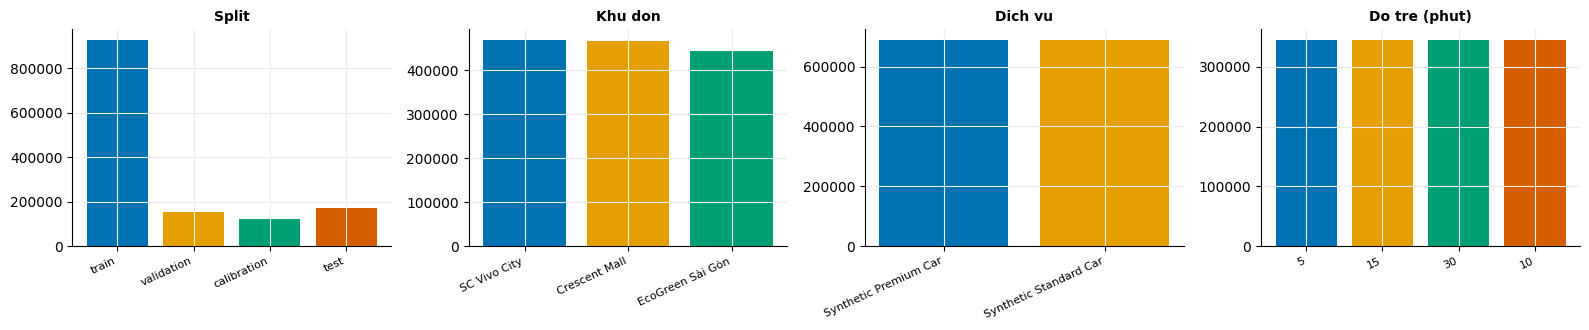

In [12]:
# Bieu do tong quan
fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))
for a,(col,ten,order) in zip(ax, [
        ("split","Split",["train","validation","calibration","test"]),
        ("pickup_location_name","Khu don",None),
        ("service_name","Dich vu",None),
        ("requested_lag_minutes","Do tre (phut)",None)]):
    vc = df[col].value_counts()
    if order: vc = vc.reindex([o for o in order if o in vc.index])
    a.bar(range(len(vc)), vc.values, color=[BLUE,ORANGE,GREEN,RED][:len(vc)])
    a.set_xticks(range(len(vc))); a.set_xticklabels(vc.index, rotation=25, ha="right", fontsize=8)
    a.set_title(ten, fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

### Phân bố các biến TARGET (giá VND & hệ số nhân)

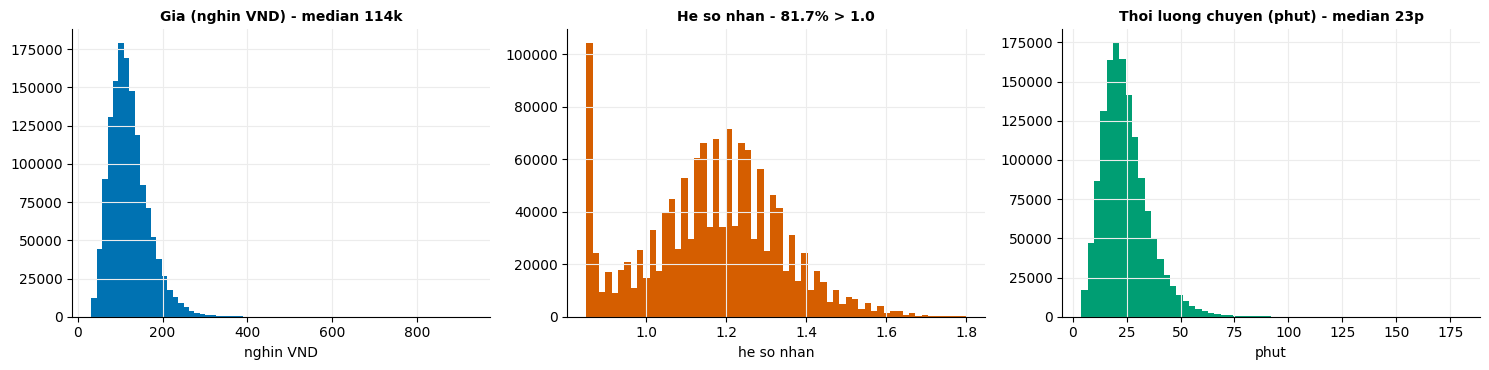

Gia: 32k - 928k VND
Ty le surge (>1.0): 81.7%  (Boston cu ~13.5%)


In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].hist(df.target_shown_price/1000, bins=70, color=BLUE)
ax[0].set_title(f"Gia (nghin VND) - median {df.target_shown_price.median()/1000:.0f}k", fontweight="bold", fontsize=10)
ax[0].set_xlabel("nghin VND")
ax[1].hist(df.target_shown_multiplier, bins=60, color=RED)
ax[1].set_title(f"He so nhan - {(df.target_shown_multiplier>1).mean()*100:.1f}% > 1.0", fontweight="bold", fontsize=10)
ax[1].set_xlabel("he so nhan")
ax[2].hist((df.quote_duration/60), bins=60, color=GREEN)
ax[2].set_title(f"Thoi luong chuyen (phut) - median {df.quote_duration.median()/60:.0f}p", fontweight="bold", fontsize=10)
ax[2].set_xlabel("phut")
plt.tight_layout(); plt.show()

print(f"Gia: {df.target_shown_price.min()/1000:.0f}k - {df.target_shown_price.max()/1000:.0f}k VND")
print(f"Ty le surge (>1.0): {(df.target_shown_multiplier>1).mean()*100:.1f}%  (Boston cu ~13.5%)")

---
## 2b. Thống kê theo NỀN TẢNG ĐỐI THỦ & LOẠI DỊCH VỤ

Xem cơ cấu, giá, hệ số nhân, quãng đường/thời lượng theo **nền tảng đối thủ** và **từng dịch vụ**.

In [14]:
# --- Theo NEN TANG DOI THU ---
plat = df.groupby("competitor_platform").agg(
    so_dong=("target_shown_price","size"),
    gia_median_VND=("target_shown_price","median"),
    gia_mean_VND=("target_shown_price","mean"),
    surge_rate=("target_shown_multiplier", lambda s:(s>1).mean()),
    surge_mean=("target_shown_multiplier","mean")).round(1)
plat["ty_le_%"] = (plat.so_dong/len(df)*100).round(1)
print(f"So nen tang doi thu: {df.competitor_platform.nunique()}")
if df.competitor_platform.nunique()==1:
    print("-> Chi co 1 doi thu duy nhat trong dataset ('Synthetic Competitor').")
display(plat)

So nen tang doi thu: 1
-> Chi co 1 doi thu duy nhat trong dataset ('Synthetic Competitor').


,so_dong,gia_median_VND,gia_mean_VND,surge_rate,surge_mean,ty_le_%
competitor_platform,,,,,,
Synthetic Competitor,1379423,114000.0,121356.7,0.8,1.2,100.0


### Theo loại dịch vụ (Standard vs Premium)

In [15]:
# --- Theo DICH VU ---
svc = df.groupby("service_name").agg(
    so_dong=("target_shown_price","size"),
    gia_median_VND=("target_shown_price","median"),
    gia_per_km_VND=("target_price_per_km","median"),
    surge_rate=("target_shown_multiplier", lambda s:(s>1).mean()),
    surge_mean=("target_shown_multiplier","mean"),
    quang_duong_m=("quote_distance","median"),
    thoi_luong_phut=("quote_duration", lambda s: s.median()/60)).round(2)
svc["ty_le_%"] = (svc.so_dong/len(df)*100).round(1)
print("THONG KE THEO DICH VU:")
display(svc)

THONG KE THEO DICH VU:


,so_dong,gia_median_VND,gia_per_km_VND,surge_rate,surge_mean,quang_duong_m,thoi_luong_phut,ty_le_%
service_name,,,,,,,,
Synthetic Premium Car,689845,113000.0,18082.92,0.81,1.16,6.17,22.09,50.0
Synthetic Standard Car,689578,116000.0,18509.73,0.82,1.17,6.17,23.52,50.0


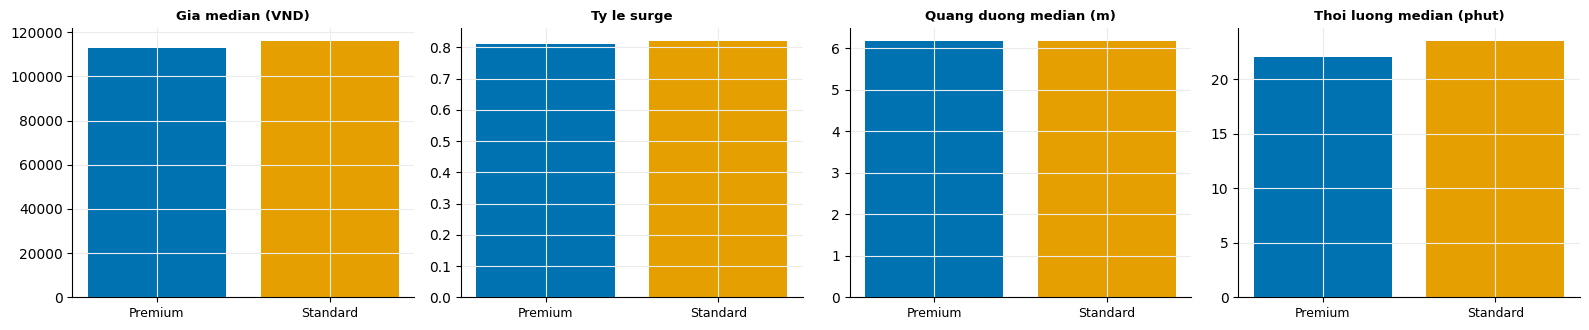

In [16]:
# Bieu do so sanh dich vu
fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))
svc_sorted = df.groupby("service_name")
labels = list(svc.index)
cols = [BLUE, ORANGE][:len(labels)]

data = [("gia_median_VND","Gia median (VND)"),
        ("surge_rate","Ty le surge"),
        ("quang_duong_m","Quang duong median (m)"),
        ("thoi_luong_phut","Thoi luong median (phut)")]
for a,(colname,ten) in zip(ax, data):
    vals = svc[colname].values
    a.bar(range(len(labels)), vals, color=cols)
    a.set_xticks(range(len(labels))); a.set_xticklabels([l.replace("Synthetic ","").replace(" Car","") for l in labels], fontsize=9)
    a.set_title(ten, fontweight="bold", fontsize=9.5)
plt.tight_layout(); plt.show()

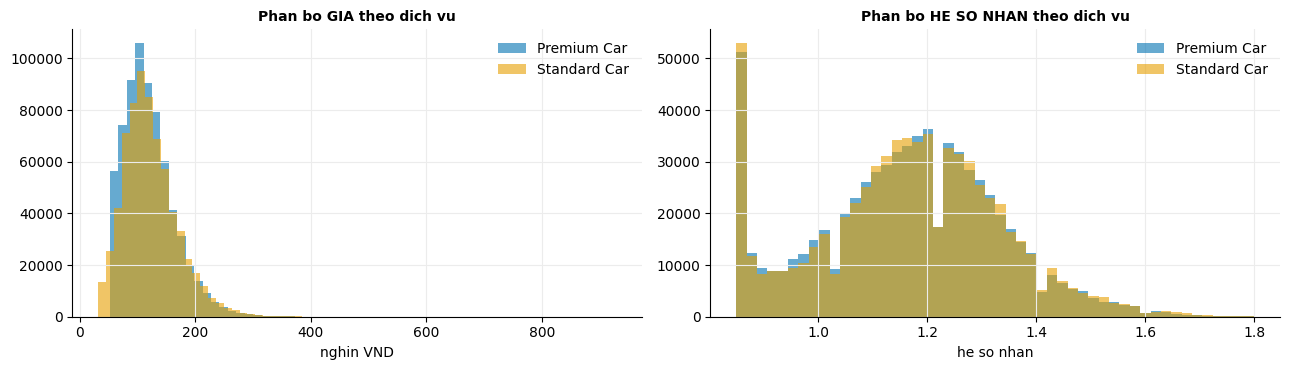

In [17]:
# Phan bo gia theo dich vu (overlay)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
for svc_name, c in zip(labels, cols):
    d = df[df.service_name==svc_name]
    ax[0].hist(d.target_shown_price/1000, bins=60, alpha=.6, label=svc_name.replace("Synthetic ",""), color=c)
    ax[1].hist(d.target_shown_multiplier, bins=50, alpha=.6, label=svc_name.replace("Synthetic ",""), color=c)
ax[0].set_title("Phan bo GIA theo dich vu", fontweight="bold", fontsize=10); ax[0].set_xlabel("nghin VND"); ax[0].legend(frameon=False)
ax[1].set_title("Phan bo HE SO NHAN theo dich vu", fontweight="bold", fontsize=10); ax[1].set_xlabel("he so nhan"); ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

---
# 3️⃣ Dữ liệu thiếu

Kiểm tra từng trường có bao nhiêu % thiếu — quyết định xử lý (bỏ / điền / giữ).

In [18]:
miss = (df.isna().mean()*100).sort_values(ascending=False)
miss_nonzero = miss[miss > 0]
print(f"Tong {df.shape[1]} cot | {len(miss_nonzero)} cot CO thieu | {df.shape[1]-len(miss_nonzero)} cot day du")
if len(miss_nonzero):
    display(miss_nonzero.round(3).to_frame("thieu_%"))
else:
    print("Khong cot nao thieu du lieu.")

Tong 70 cot | 0 cot CO thieu | 70 cot day du
Khong cot nao thieu du lieu.


In [19]:
# Bieu do cot thieu (neu co)
if len(miss_nonzero):
    fig, ax = plt.subplots(figsize=(9, max(2.2, len(miss_nonzero)*0.32)))
    ax.barh(range(len(miss_nonzero)), miss_nonzero.values, color=RED)
    ax.set_yticks(range(len(miss_nonzero))); ax.set_yticklabels(miss_nonzero.index, fontsize=9)
    ax.set_xlabel("% thieu"); ax.invert_yaxis()
    ax.set_title("Cac cot co du lieu thieu", fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("Khong co cot thieu -> khong ve bieu do.")

Khong co cot thieu -> khong ve bieu do.


In [20]:
# Thieu do THOI TIET (weather_missing la co-che rieng cua dataset)
if "weather_missing" in df.columns:
    wm = df.weather_missing.mean()*100
    print(f"weather_missing = 1 (thoi tiet khong quan sat duoc kip): {wm:.2f}% so dong")
    print(f"  -> {int(df.weather_missing.sum()):,} dong bi thieu quan sat thoi tiet")
    print("  Ly do: dataset mo phong ty le fail quan sat thoi tiet ~5% (xem generation_config).")
# Ket luan
print("\n" + "="*56)
print("KET LUAN DU LIEU THIEU:")
if len(miss_nonzero)==0:
    print("  - Cac cot chinh: 0% thieu -> rat sach.")
print("  - Thoi tiet co the thieu (co san cot weather_missing de danh dau).")
print("  - Cach xu ly: giu weather_missing lam feature; cot thoi tiet thieu -> model cay tu xu ly NaN.")

weather_missing = 1 (thoi tiet khong quan sat duoc kip): 1.71% so dong
  -> 23,638 dong bi thieu quan sat thoi tiet
  Ly do: dataset mo phong ty le fail quan sat thoi tiet ~5% (xem generation_config).

KET LUAN DU LIEU THIEU:
  - Cac cot chinh: 0% thieu -> rat sach.
  - Thoi tiet co the thieu (co san cot weather_missing de danh dau).
  - Cach xu ly: giu weather_missing lam feature; cot thoi tiet thieu -> model cay tu xu ly NaN.


---
## Tóm tắt

- **Bộ dữ liệu sạch**: các cột chính gần như 0% thiếu; chỉ thời tiết có thể thiếu (~5%, đã đánh
  dấu bằng `weather_missing`).
- **Đủ 2 mắt xích Boston thiếu**: `quote_duration` + cung–cầu (`pricing_*`).
- **Surge phổ biến** (khác Boston) → model hệ số nhân sẽ có nhiều tín hiệu hơn.
- **Sẵn sàng train**: split, lag/history, baseline `persistence_prediction`, độ trễ đều có sẵn.

→ Bước tiếp theo: xây pipeline train trên bộ này (giữ kiến trúc cũ: model giá + surge 2 tầng +
conformal), tận dụng duration & cung–cầu để vượt trần của bộ Boston.